In [1]:
import pandas as pd
import requests
import sys, os
import time
from tqdm import tqdm

sys.path.append(os.path.abspath("../src"))

In [ ]:
API = "https://en.wikipedia.org/w/api.php"
HEADERS = {"User-Agent": "thinking-bee/0.1 (t.j.wies@gmail.com)"}

def get_template_links(template_title: str) -> list[str]:
    '''Given a wikipedia template title, returns list of page links related to the template'''
    params = {
        "action": "query",
        "format": "json",
        "prop": "links",
        "titles": template_title,
        "pllimit": "max",
        "plnamespace": 0,   # main/article namespace only
        "formatversion": 2,
    }

    titles = []
    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=20)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages:
            links = pages[0].get("links", [])
            titles.extend(link["title"] for link in links)

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    return sorted(set(titles))

def get_revision_diff(parent_id, rev_id):
    """Fetch the HTML diff between two Wikipedia revisions.

    Args:
        parent_id (int): Revision ID of the parent revision.
        rev_id (int): Revision ID to compare against the parent revision.

    Returns:
        str | None: HTML diff markup if available, otherwise None.
    """
    params = {
        "action": "compare",
        "format": "json",
        "fromrev": parent_id,
        "torev": rev_id,
        "prop": "diff|ids|title",
        "formatversion": "2",
    }

    resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    compare = data.get("compare", {})
    return compare.get("*") or compare.get("body") or compare.get("diff")


def get_revisions(page_title, talk=False, include_diff=False, sleep_sec=0.0):
    """Fetch Wikipedia revision history for a page.

    Args:
        page_title (str): Title of the Wikipedia page.
        talk (bool, optional): If True, fetch revisions from the talk page. Defaults to False.
        include_diff (bool, optional): If True, include HTML diffs for each revision. Defaults to False.
        sleep_sec (float, optional): Seconds to sleep between API calls when fetching diffs. Defaults to 0.0.

    Returns:
        pd.DataFrame: DataFrame containing revision history with columns: revid, parentid, timestamp, user, 
                      comment, size, page_title, diff_html (if include_diff=True), comment_len, has_reply, 
                      has_revert, and size_change.
    """
    if talk and not page_title.startswith("Talk:"):
        page_title = "Talk:" + page_title

    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": page_title,
        "rvprop": "ids|timestamp|user|comment|size",
        "rvlimit": "max",
        "formatversion": "2",
    }

    all_revisions = []

    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages and "revisions" in pages[0]:
            all_revisions.extend(pages[0]["revisions"])

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    df = pd.DataFrame(all_revisions)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["page_title"] = page_title

    if include_diff:
        diffs = []
        for _, row in df.iterrows():
            rev_id = row.get("revid")
            parent_id = row.get("parentid")

            if pd.isna(rev_id) or pd.isna(parent_id) or parent_id == 0:
                diffs.append(None)
            else:
                try:
                    diff_html = get_revision_diff(int(parent_id), int(rev_id))
                    diffs.append(diff_html)
                    if sleep_sec > 0:
                        time.sleep(sleep_sec)
                except Exception:
                    diffs.append(None)

        df["diff_html"] = diffs

    df["comment"] = df["comment"].fillna("")
    df["comment_len"] = df["comment"].str.len()
    df["has_reply"] = df["comment"].str.contains("Reply", case=False, regex=False).astype(int)
    df["has_revert"] = df["comment"].str.contains("revert", case=False, regex=True).astype(int)
    df["size_change"] = df["size"].diff().abs()

    return df

def format_revisions(revisions: pd.DataFrame | None) -> pd.DataFrame:
    """
    Format revision history into hourly aggregated features.

    Args:
        revisions (pd.DataFrame | None): DataFrame from get_revisions containing revision data, or None.

    Returns:
        pd.DataFrame: Hourly aggregated features including edits, unique_editors, new_editors, 
                      total_comment_len, num_replies, num_reverts, sorted by timestamp.
    """
    if revisions is None:
        return pd.DataFrame()
    if revisions.empty:
        return revisions
    df = revisions
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    df["timestamp"] = df["timestamp"].dt.floor("h")
    edits = df.groupby("timestamp").size().rename("edits")
    unique_editors = df.groupby("timestamp")["user"].nunique().rename("unique_editors")

    df["seen_before"] = df["user"].duplicated()
    df["new_editor"] = (~df["seen_before"]).astype(int)
    new_editors = df.groupby("timestamp")["new_editor"].sum().rename("new_editors")
    total_comment_len = df.groupby("timestamp")["comment_len"].sum().rename("total_comment_len")
    num_replies = df.groupby("timestamp")["has_reply"].sum().rename("num_replies")
    num_reverts = df.groupby("timestamp")["has_revert"].sum().rename("num_reverts")
    features = pd.concat([edits, unique_editors, new_editors, total_comment_len, num_replies, num_reverts], axis=1).fillna(0)

    return features.reset_index().sort_values("timestamp")

In [ ]:
''' commented out until ready to retrieve new wiki data'''
# titles = get_template_links("Template:Campaignbox 2026 Iran war")
# from tqdm import tqdm
# all_revisions = []
# features = pd.DataFrame()
# for i in tqdm(titles):
#     rev = get_revisions(i, talk=False, include_diff=False, sleep_sec=0)
#     talk_rev = get_revisions(i, talk=True, include_diff=False, sleep_sec=0)

#     if not rev.empty:
#         all_revisions.append(rev)
#     if not talk_rev.empty:
#         all_revisions.append(talk_rev)

In [5]:
all_revisions = pd.read_csv(os.path.join("..", "data", "features.csv"))
print(all_revisions.shape)
all_revisions.head()

(26660, 13)


,Unnamed: 0,revid,parentid,user,timestamp,size,comment,anon,page_title,diff_html,temp,userhidden,commenthidden
0,0,1344799148,1343955798,Fróis,2026-03-22 16:31:31+00:00,45078,/* Merge proposal */ Reply,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
1,1,1343955798,1343919767,Lova Falk,2026-03-17 11:49:32+00:00,44939,/* Merge proposal */ reply,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
2,2,1343919767,1343061185,Thebiguglyalien,2026-03-17 04:58:47+00:00,44828,/* Merge proposal */ Reply,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
3,3,1343061185,1343060908,Longhornsg,2026-03-12 01:29:13+00:00,44447,/* Merge proposal */ +,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
4,4,1343060908,1342488357,Longhornsg,2026-03-12 01:27:13+00:00,44406,/* Merge proposal */ new section,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN


In [6]:
import re

def contains_keywords(text, keywords):
    if not isinstance(text, str):
        return 0
    pattern = "|".join(map(re.escape, keywords))
    return int(bool(re.search(pattern, text, flags=re.IGNORECASE)))

escalation_words = [
    "attack", "strike", "missile", "nuclear", "war", "bomb", "military"
]

uncertainty_words = [
    "report", "unconfirmed", "alleged", "rumor", "claim", "possible"
]

all_revisions["comment"] = all_revisions["comment"].fillna("")

all_revisions["has_escalation"] = all_revisions["comment"].apply(
    lambda x: contains_keywords(x, escalation_words)
)

all_revisions["has_uncertainty"] = all_revisions["comment"].apply(
    lambda x: contains_keywords(x, uncertainty_words)
)

all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

all_revisions["comment_len"] = all_revisions["comment"].str.len()
all_revisions["has_reply"] = all_revisions["comment"].str.contains("Reply", case=False).astype(int)
all_revisions["has_revert"] = all_revisions["comment"].str.contains("revert", case=False, regex=True).astype(int)

all_revisions["size_change"] = all_revisions["size"].diff().abs()

all_revisions["timestamp"] = pd.to_datetime(all_revisions["timestamp"], utc=True)
all_revisions = all_revisions.sort_values("timestamp")
all_revisions["timestamp"] = all_revisions["timestamp"].dt.floor("h")

features = all_revisions.groupby("timestamp").agg(
    edits=("user", "count"),
    unique_editors=("user", "nunique"),
    new_editors=("new_editor_global", "sum"),
    num_seen_before_global=("seen_before_global", "sum"),
    total_comment_len=("comment_len", "sum"),
    avg_comment_len=("comment_len", "mean"),
    num_replies=("has_reply", "sum"),
    num_reverts=("has_revert", "sum"),
    num_escalation_comments=("has_escalation", "sum"),
    num_uncertainty_comments=("has_uncertainty", "sum"),
    total_size_change=("size_change", "sum"),
    max_size_change=("size_change", "max"),
).reset_index().sort_values("timestamp")
print(features.shape)
features.head()


(3386, 13)


,timestamp,edits,unique_editors,new_editors,num_seen_before_global,total_comment_len,avg_comment_len,num_replies,num_reverts,num_escalation_comments,num_uncertainty_comments,total_size_change,max_size_change
0,2004-10-02 18:00:00+00:00,2,1,1,1,54,27.0,0,0,0,0,410.0,205.0
1,2005-01-28 17:00:00+00:00,4,1,1,3,26,6.5,0,0,2,0,504.0,234.0
2,2006-01-09 16:00:00+00:00,2,1,1,1,0,0.0,0,0,0,0,1040.0,520.0
3,2006-01-30 22:00:00+00:00,2,1,1,1,0,0.0,0,0,0,0,2580.0,1290.0
4,2006-02-12 15:00:00+00:00,2,1,0,2,128,64.0,0,0,2,0,0.0,0.0


In [7]:
import importlib
import poly_utils
importlib.reload(poly_utils)
from poly_utils import get_event_slugs_paginated, get_price_series_from_slug

market_dfs = []
slugs = get_event_slugs_paginated("Iran", pages=10, limit=100)

for slug in tqdm(slugs):
    slug = slug["slug"]
    prices, meta = get_price_series_from_slug(
        slug=slug,
        days=60,
        chunk_days=7,
        interval="1h",
        fidelity=60,
    )
    market_df = prices.copy()
    market_df["market_slug"] = slug
    market_df["market_title"] = meta["market_question"]

    # compute target within this market
    market_df = market_df.sort_values("timestamp")
    # market_df["volatility_6h"] = market_df["price"].diff().rolling(6).std()
    # market_df["target"] = market_df["volatility_6h"].shift(-1)

    market_dfs.append(market_df)

100%|██████████| 10/10 [00:22<00:00,  2.28s/it]


In [8]:
panel_df = pd.concat(market_dfs, ignore_index=True)
print(panel_df.shape)
panel_df.head()

(10587, 4)


/var/folders/1r/k6vlr74j5_j3ftfp83kg694m0000gn/T/ipykernel_16377/2191102582.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  panel_df = pd.concat(market_dfs, ignore_index=True)


,timestamp,price,market_slug,market_title
0,2026-03-09 17:00:51+00:00,0.385,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
1,2026-03-09 18:00:44+00:00,0.375,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
2,2026-03-09 19:00:33+00:00,0.365,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
3,2026-03-09 20:00:34+00:00,0.345,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
4,2026-03-09 21:00:46+00:00,0.355,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?


In [9]:
def validate_and_resample_panel(panel_df, freq="1h"):
    panel_df = panel_df.copy()
    panel_df["timestamp"] = pd.to_datetime(panel_df["timestamp"], utc=True)

    cleaned = []

    for slug, g in panel_df.groupby("market_slug"):
        print("\n" + "=" * 80)
        print("Market:", slug)
        print("Rows:", len(g))
        print("Time range:", g["timestamp"].min(), "→", g["timestamp"].max())

        g = g.sort_values("timestamp").drop_duplicates("timestamp").copy()
        g["delta"] = g["timestamp"].diff()

        print("\nUnique time deltas:")
        print(g["delta"].value_counts().head())

        expected = pd.Timedelta(freq)
        gaps = g[g["delta"] > expected]

        print(f"\nNumber of gaps > {freq}: {len(gaps)}")
        if len(gaps) > 0:
            print("\nExample gaps:")
            print(gaps[["timestamp", "delta"]].head())

        print("\nDuplicate timestamps:", g["timestamp"].duplicated().sum())

        # keep non-time metadata columns
        meta_cols = [c for c in g.columns if c not in ["timestamp", "price", "delta"]]

        g_clean = (
            g.set_index("timestamp")
            .resample(freq)
            .last()
            .ffill()
            .reset_index()
        )

        # restore market_slug if needed
        g_clean["market_slug"] = slug

        print("\nAfter resampling:")
        print("Rows:", len(g_clean))

        print("\nFinal time delta check:")
        print(g_clean["timestamp"].diff().value_counts().head())

        cleaned.append(g_clean)

    return pd.concat(cleaned, ignore_index=True)


panel_clean = validate_and_resample_panel(panel_df, freq="1h")

panel_clean = panel_clean.sort_values(["market_slug", "timestamp"])
panel_clean["volatility_6h"] = (
    panel_clean.groupby("market_slug")["price"]
    .transform(lambda s: s.diff().rolling(6).std())
)

panel_clean["target"] = (
    panel_clean.groupby("market_slug")["volatility_6h"]
    .shift(-1)
)


Market: iran-nuclear-test-before-2027
Rows: 1375
Time range: 2026-03-09 17:00:49+00:00 → 2026-05-08 16:07:05+00:00

Unique time deltas:
delta
0 days 01:00:00    153
0 days 01:00:01    126
0 days 00:59:59    110
0 days 01:00:02     97
0 days 00:59:58     88
Name: count, dtype: int64

Number of gaps > 1h: 645

Example gaps:
                     timestamp           delta
3431 2026-03-09 20:00:33+00:00 0 days 01:00:01
3432 2026-03-09 21:00:44+00:00 0 days 01:00:11
3434 2026-03-09 23:00:33+00:00 0 days 01:00:02
3435 2026-03-10 00:00:50+00:00 0 days 01:00:17
3437 2026-03-10 02:00:32+00:00 0 days 01:00:01

Duplicate timestamps: 0

After resampling:
Rows: 1440

Final time delta check:
timestamp
0 days 01:00:00    1439
Name: count, dtype: int64

Market: iran-nuke-before-2027
Rows: 1103
Time range: 2026-03-09 17:00:42+00:00 → 2026-05-08 16:07:06+00:00

Unique time deltas:
delta
0 days 01:00:01    82
0 days 01:00:00    71
0 days 00:59:59    70
0 days 01:00:02    64
0 days 00:59:58    51
Name: co

In [10]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Merge prices + features
# -----------------------------
# Assumes:
# panel_clean has: timestamp, market_slug, price
# features has: timestamp, edits, unique_editors, new_editors, etc.
# If features are global to all markets, merge only on timestamp.
# If features are market-specific, include market_slug and merge by market_slug too.

prices_hourly = panel_clean.copy()
prices_hourly["timestamp"] = pd.to_datetime(prices_hourly["timestamp"], utc=True)

features_hourly = (
    features.copy()
    .assign(timestamp=lambda x: pd.to_datetime(x["timestamp"], utc=True))
    .set_index("timestamp")
    .resample("1h")
    .sum()
    .fillna(0)
    .reset_index()
)

df = pd.merge_asof(
    prices_hourly.sort_values("timestamp"),
    features_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df = df.sort_values(["market_slug", "timestamp"]).copy()

# cutoff datapoints without matching wiki csv data
cutoff = pd.Timestamp("2026-04-09", tz="UTC")
df = df.loc[df["timestamp"] < cutoff].copy()

windows = {
    "1h": 1,
    "3h": 3,
    "6h": 6,
    # "12h": 12,
    # "24h": 24,
}

wiki_cols = list(features.columns)[1:]

new_cols = {}

# returns must be within market
new_cols["returns"] = (
    df.groupby("market_slug")["price"]
    .pct_change()
)

for label, hours in windows.items():
    g = df.groupby("market_slug", group_keys=False)

    # price targets / volatility
    new_cols[f"delta_price_{label}"] = (
        g["price"].shift(-hours) - df["price"]
    )

    new_cols[f"abs_delta_price_move_{label}"] = (
        new_cols[f"delta_price_{label}"].abs()
    )

    new_cols[f"volatility_{label}"] = (
        new_cols["returns"]
        .groupby(df["market_slug"])
        .rolling(hours, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

    # wiki rolling features
    for col in wiki_cols:
        rolled = (
            df[col]
            .groupby(df["market_slug"])
            .rolling(hours, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        new_cols[f"{col}_{label}"] = rolled
        new_cols[f"{col}_{label}_diff"] = (
            rolled.groupby(df["market_slug"]).diff()
        )

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1).copy()
print(df.shape)
df.tail()

wiki_cols

(6543, 101)


['edits',
 'unique_editors',
 'new_editors',
 'num_seen_before_global',
 'total_comment_len',
 'avg_comment_len',
 'num_replies',
 'num_reverts',
 'num_escalation_comments',
 'num_uncertainty_comments',
 'total_size_change',
 'max_size_change']

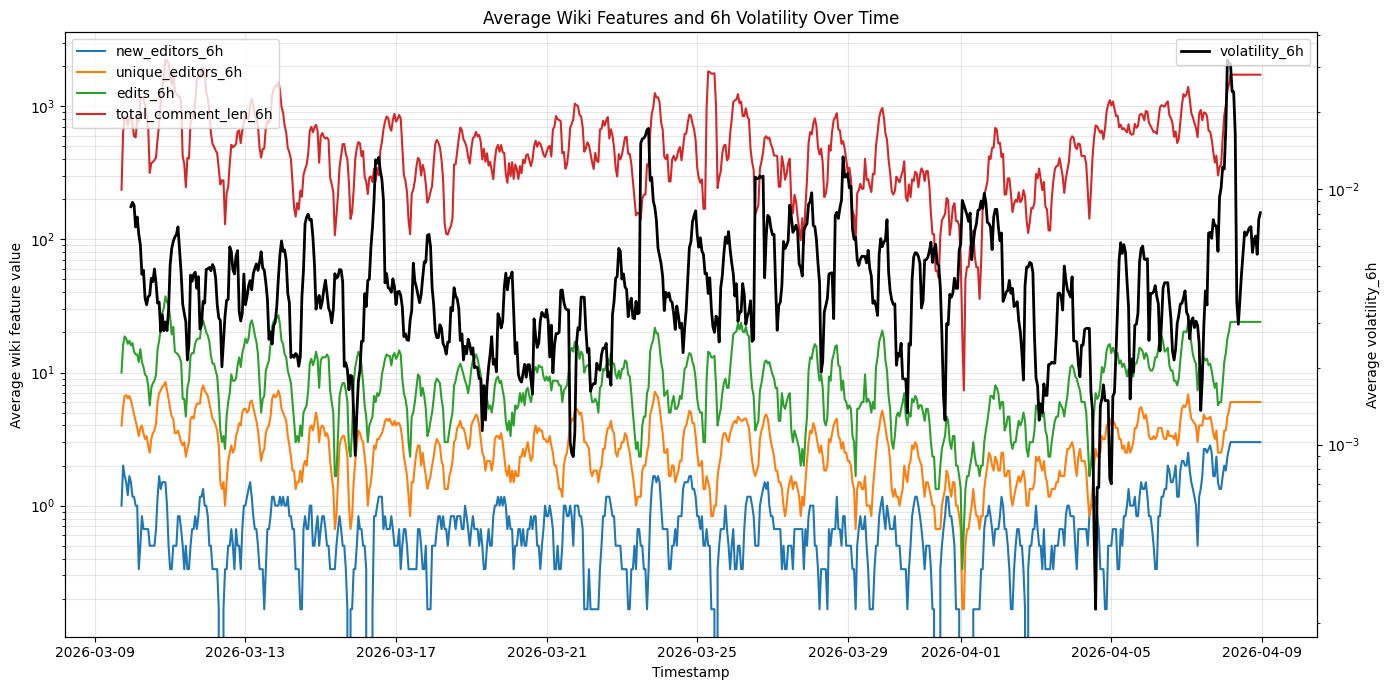

In [11]:
import matplotlib.pyplot as plt
df = df.loc[:, ~df.columns.duplicated()].copy()
features_to_plot = [
    "new_editors_6h",
    "unique_editors_6h",
    "edits_6h",
    "total_comment_len_6h",
]
agg = (
    df.sort_values("timestamp")
      .groupby("timestamp")[features_to_plot + ["volatility_6h"]]
      .mean()
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 7))

for feature in features_to_plot:
    ax1.plot(agg["timestamp"], agg[feature], label=feature, linewidth=1.5)

ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Average wiki feature value")
ax1.set_yscale("log")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3, which="both")

ax2 = ax1.twinx()
ax2.plot(agg["timestamp"], agg["volatility_6h"], label="volatility_6h", color="black", linewidth=2)
ax2.set_ylabel("Average volatility_6h")
ax2.set_yscale("log")
ax2.legend(loc="upper right")

plt.title("Average Wiki Features and 6h Volatility Over Time")
plt.tight_layout()
plt.show()

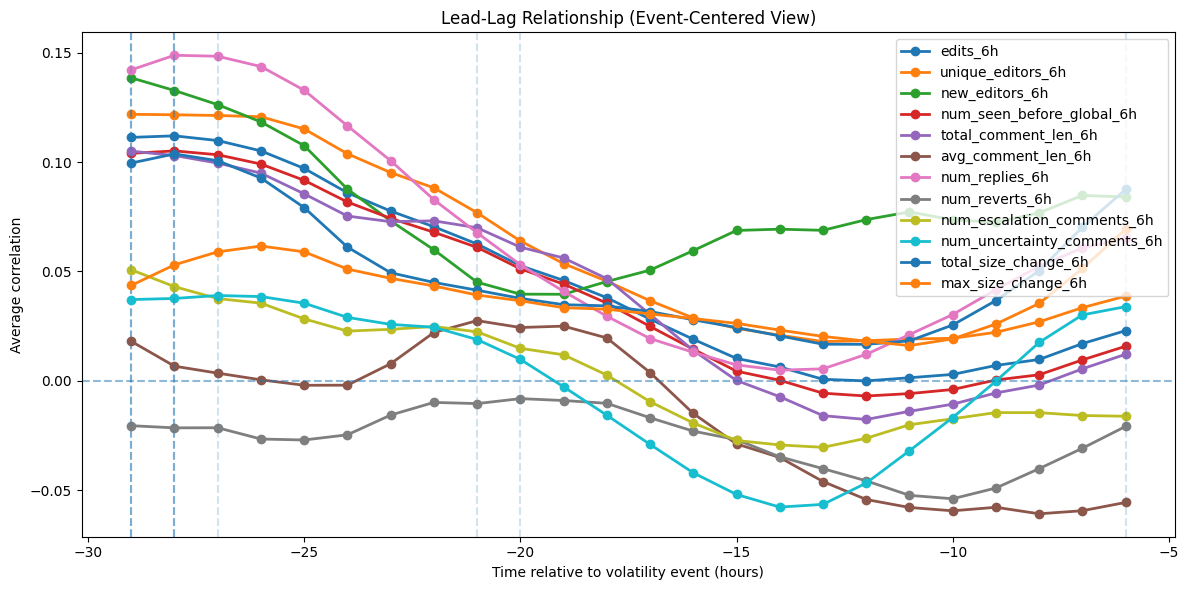

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = df.loc[:, ~df.columns.duplicated()].copy()

features_to_plot = [col + "_6h" for col in wiki_cols]

max_lag = 24
target_horizon = 6

plt.figure(figsize=(12, 6))

for feature in features_to_plot:
    market_corrs = {}

    for slug, g in df.groupby("market_slug"):
        g = g.sort_values("timestamp").copy()

        target = g["volatility_6h"].shift(-target_horizon)

        corrs = []
        for lag in range(max_lag):
            x = g[feature].shift(lag)
            corrs.append(x.corr(target))

        market_corrs[slug] = corrs

    corr_df = pd.DataFrame(market_corrs)
    avg_corr = corr_df.mean(axis=1)

    # NEGATIVE time axis
    time_to_event = -(np.arange(max_lag) + target_horizon)

    plt.plot(
        time_to_event,
        avg_corr,
        marker="o",
        linewidth=2,
        label=feature
    )

    # mark strongest signal
    best_idx = np.argmax(avg_corr)
    best_time = -(best_idx + target_horizon)
    plt.axvline(best_time, linestyle="--", alpha=0.2)

plt.axhline(0, linestyle="--", alpha=0.5)

plt.xlabel("Time relative to volatility event (hours)")
plt.ylabel("Average correlation")
plt.title("Lead-Lag Relationship (Event-Centered View)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# remove duplicate dataframe columns from repeated cell runs
df = df.loc[:, ~df.columns.duplicated()].copy()

### Text Processing with SVD

In [14]:
import re
from html import unescape
def remove_wiki_usernames(text):
    return re.sub(r"\b[a-zA-Z]*editor\d+\b", " ", text, flags=re.IGNORECASE)

def clean_html(text):
    if not isinstance(text, str):
        return ""

    # Unescape HTML entities (&amp;, &lt;, etc.)
    text = unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove leftover markup artifacts
    text = re.sub(r"\{\{.*?\}\}", " ", text)   # templates
    text = re.sub(r"\[\[|\]\]", " ", text)     # wiki links
    text = re.sub(r"\|", " ", text)

    # Keep only words (remove weird punctuation)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text.lower()

def extract_added_text(html):
    if not isinstance(html, str):
        return ""

    added = re.findall(r"<ins[^>]*>(.*?)</ins>", html, flags=re.DOTALL)
    added_text = " ".join(added)

    return clean_html(added_text)
    
    

In [15]:
WIKI_STOP_WORDS = {
    "yes",
    "no",
    "ok",
    "right",
    "current",
    "official",
    "claim",
    "opinion",
    "involve",
    "article",
    "source",
    "editor",
    "page",
    "discussion",
    "consensus",
    "citation",
    "include",
    "remove",
    "added",
    "deleted",
    "section",
    "content",
    "okay",
    "done",
    "fixed",
    "added",
    "removed",
    "update",
    "updated",
    "change",
    "changed",
    "edit",
    "edited",
    "user",
    "wikipedia",
    "war",
    "revert",
    "rv",
    "undo",
    "undid",
    "restored",
    "consensus",
    "discussion",
    "talk",
    "page",
    "per",
    "per wp",
    "per policy",
    "see talk",
    "source",
    "sources",
    "citation",
    "cited",
    "reliable",
    "unreliable",
    "rs",
    "wp",
    "npov",
    "neutral",
    "bias",
    "biased",
    "undue",
    "weight",
    "stub",
    "cleanup",
    "expand",
    "expanded",
    "tag",
    "tagged",
    "template",
    "infobox",
    "citation needed",
    "cn",
    "ref",
    "refs",
    "commment",
    "html",
    "nbsp",
    "br",
    "div",
    "span",
    "table",
    "row",
    "col",
    "class",
    "style",
    "utc",
    "january",
    "february",
    "march",
    "april",
    "may",
    "june",
    "july",
    "august",
    "september",
    "october",
    "november",
    "december",
    "cameron",
    "reply",
    "title",
    "day",
    "fa",
    "hrana",
    "abo",
    "thday",
    "low",
    "importance",
    "high",
    "mid",
    "archived",
    "elli",
    "article",
    "section",
    "entry",
    "add",
    "please",
    "thanks",
    "thank",
    "help",
    "agree",
    "disagree",
    "support",
    "oppose",
    "question",
    "answer",
    "answered",
    "using",
    "used",
    "work",
    "working",
    "want",
    "like",
    "make",
    "made",
    "time",
    "times",
    "new",
    "old",
    "edit",
    "edited",
    "revert",
    "rv",
    "undo",
    "page",
    "talk",
    "wp",
    "rs",
    "ref",
    "template",
    "yes",
    "no",
    "ok",
    "thanks",
    "please",
    "fa",
    "abo",
    "utc",
    "make",
    "use",
    "work",
    "want",
    "comment",
    "contribution",
    "contributions",
    "special",
    "signature",
    "signatures",
    "preceding",
    "unsigned",
    "contrib",
    "contribs",
    "permalink",
    "destination",
    "requested",
    "rfcid",
    "ans",
    "blp",
    "collapsed",
    "relisting",
    "country",
    "government",
    "state",
    "article",
    "source",
    "editor",
    "discussion",
    "page",
    "citation",
    "mention",
    "list",
}
import spacy


def looks_like_username(token):
    return len(token) > 10 or any(char.isdigit() for char in token)


nlp = spacy.load("en_core_web_sm", disable=["parser"])


def spacy_tokenizer(text):
    doc = nlp(text)
    custom_stop = WIKI_STOP_WORDS
    tokens = []
    entity_spans = set()

    # preserve named entities as full phrases
    for ent in doc.ents:
        if ent.label_ in {"PERSON", "GPE", "ORG", "NORP", "LOC", "EVENT"}:
            ent_text = ent.text.lower().replace(" ", "_")

            if (
                len(ent_text) > 2
                and ent_text not in custom_stop
                and not looks_like_username(ent_text)
            ):
                tokens.append(ent_text)

            for token in ent:
                entity_spans.add(token.i)

    # process non-entity tokens WITHOUT lemmatization
    for token in doc:
        if token.i in entity_spans:
            continue

        word = token.text.lower()

        if (
            token.is_stop
            or token.is_punct
            or not word.isalpha()
            or len(word) < 3
            or len(word) > 20
            or any(ch.isdigit() for ch in word)
            or word in custom_stop
            or looks_like_username(word)
        ):
            continue

        tokens.append(word)

    return tokens

In [16]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

def build_text_svd_features_safe(
    rev_text,
    text_col,
    prefix,
    tokenizer,
    max_features=300,
    n_components=10,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 3),
):
    rev_text = rev_text.copy()
    docs = rev_text[text_col].fillna("").astype(str)

    # basic empty check
    nonempty = docs.str.strip().ne("")
    rev_text = rev_text.loc[nonempty].copy()
    docs = docs.loc[nonempty]

    if len(docs) < 5:
        print(f"Skipping {prefix}: too few documents ({len(docs)})")
        return None, None, None, None, []

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        tokenizer=tokenizer,
        token_pattern=None,
        lowercase=False,
        min_df=min_df,
        max_df=max_df,
        stop_words=None,
        ngram_range=ngram_range,
    )

    try:
        X_tfidf = vectorizer.fit_transform(docs)
    except ValueError as e:
        print(f"Skipping {prefix}: {e}")
        return None, None, None, None, []

    if X_tfidf.shape[1] < 2:
        print(f"Skipping {prefix}: only {X_tfidf.shape[1]} terms survived")
        return None, None, None, None, []

    terms = vectorizer.get_feature_names_out()

    n_components = min(n_components, X_tfidf.shape[1] - 1)

    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_svd = svd.fit_transform(X_tfidf)

    cols = [f"{prefix}_svd_{i}" for i in range(X_svd.shape[1])]

    svd_df = pd.DataFrame(
        X_svd,
        columns=cols,
        index=rev_text.index
    )

    print(f"{prefix}: docs={len(docs)}, terms={X_tfidf.shape[1]}, components={len(cols)}")

    return svd_df, vectorizer, svd, terms, cols

In [17]:
# prepare text
rev_text = all_revisions.copy()
rev_text["timestamp"] = pd.to_datetime(rev_text["timestamp"], utc=True)
rev_text["hour"] = rev_text["timestamp"].dt.floor("h")

rev_text["comment"] = rev_text["comment"].fillna("").astype(str)

rev_text["diff_html"] = rev_text.get("diff_html", "").fillna("").astype(str)
rev_text["diff_clean"] = rev_text["diff_html"].apply(extract_added_text)
rev_text["diff_clean"] = rev_text["diff_clean"].apply(remove_wiki_usernames)
rev_text["is_talk"] = rev_text["page_title"].str.startswith("Talk:")

# optional: spike-hour filter
df["edit_spike"] = (
    df.groupby("market_slug")["edits"]
    .transform(lambda s: s > s.quantile(0.9))
)

df = df.drop(
    columns=[c for c in df.columns if c.startswith(("diff_svd_", "comment_svd_", "tfidf_svd_", "article_", "talk_"))],
    errors="ignore"
)

spike_hours = df.loc[df["edit_spike"], "timestamp"].unique()
rev_text_model = rev_text[rev_text["hour"].isin(spike_hours)].copy()

# build separate SVD features for each category
text_cols = []
configs = [
    {"name": "article_diff", "is_talk": False, "text_col": "diff_clean", "prefix": "article_diff"},
    {"name": "article_comment", "is_talk": False, "text_col": "comment", "prefix": "article_comment"},
    {"name": "talk_diff", "is_talk": True, "text_col": "diff_clean", "prefix": "talk_diff"},
    {"name": "talk_comment", "is_talk": True, "text_col": "comment", "prefix": "talk_comment"},
]
text_cols = []
text_models = {}

for config in configs:
    subset = rev_text_model[rev_text_model["is_talk"] == config["is_talk"]].copy()

    svd_df, vectorizer_, svd_, terms_, cols = build_text_svd_features_safe(
        subset,
        text_col=config["text_col"],
        prefix=config["prefix"],
        tokenizer=spacy_tokenizer,
        ngram_range=(1, 3),  # start less sparse than (1,3)
        min_df=2,            # important for small subsets
    )

    if cols:
        rev_text_model = pd.concat([rev_text_model, svd_df], axis=1)
        text_cols.extend(cols)

        text_models[config["prefix"]] = {
            "vectorizer": vectorizer_,
            "svd": svd_,
            "terms": terms_,
            "cols": cols,
        }

print("Final text cols:", text_cols)
tfidf_hourly = (
    rev_text_model.groupby("hour")[text_cols]
    .mean()
    .reset_index()
    .rename(columns={"hour": "timestamp"})
)
df = df.loc[:, ~df.columns.duplicated()].copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df = pd.merge_asof(
    df.sort_values("timestamp"),
    tfidf_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df[text_cols] = df[text_cols].fillna(0)
df = df.sort_values(["market_slug", "timestamp"]).copy()

print("Text cols:", text_cols)

Skipping article_diff: too few documents (0)
Skipping article_comment: too few documents (0)
talk_diff: docs=248, terms=300, components=10
talk_comment: docs=1316, terms=300, components=10
Final text cols: ['talk_diff_svd_0', 'talk_diff_svd_1', 'talk_diff_svd_2', 'talk_diff_svd_3', 'talk_diff_svd_4', 'talk_diff_svd_5', 'talk_diff_svd_6', 'talk_diff_svd_7', 'talk_diff_svd_8', 'talk_diff_svd_9', 'talk_comment_svd_0', 'talk_comment_svd_1', 'talk_comment_svd_2', 'talk_comment_svd_3', 'talk_comment_svd_4', 'talk_comment_svd_5', 'talk_comment_svd_6', 'talk_comment_svd_7', 'talk_comment_svd_8', 'talk_comment_svd_9']
Text cols: ['talk_diff_svd_0', 'talk_diff_svd_1', 'talk_diff_svd_2', 'talk_diff_svd_3', 'talk_diff_svd_4', 'talk_diff_svd_5', 'talk_diff_svd_6', 'talk_diff_svd_7', 'talk_diff_svd_8', 'talk_diff_svd_9', 'talk_comment_svd_0', 'talk_comment_svd_1', 'talk_comment_svd_2', 'talk_comment_svd_3', 'talk_comment_svd_4', 'talk_comment_svd_5', 'talk_comment_svd_6', 'talk_comment_svd_7', 'talk

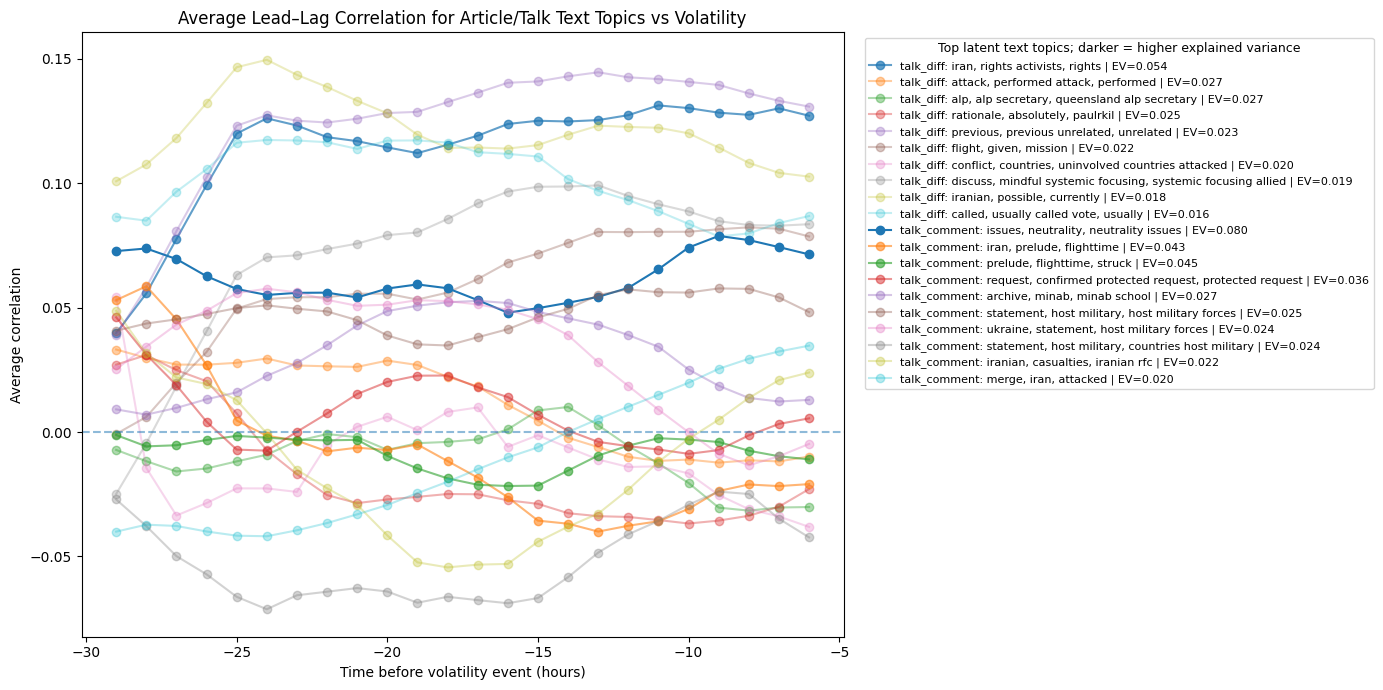

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

max_lag = 24
target_horizon = 6
time_to_event = -(np.arange(max_lag) + target_horizon)

def top_words_for_component(svd, terms, topic_idx, top_n=4):
    weights = svd.components_[topic_idx]
    top_idx = np.argsort(np.abs(weights))[::-1][:top_n]
    return ", ".join(terms[j] for j in top_idx)

# collect explained variance across all text models for shared scaling
all_explained = np.concatenate([
    model_obj["svd"].explained_variance_ratio_
    for model_obj in text_models.values()
])

ev_min = all_explained.min()
ev_max = all_explained.max()

def alpha_from_explained(ev, min_alpha=0.25, max_alpha=1.0):
    if ev_max == ev_min:
        return max_alpha
    scaled = (ev - ev_min) / (ev_max - ev_min)
    return min_alpha + scaled * (max_alpha - min_alpha)

plt.figure(figsize=(14, 7))

for model_name, model_obj in text_models.items():
    cols = model_obj["cols"]
    svd = model_obj["svd"]
    terms = model_obj["terms"]
    explained = svd.explained_variance_ratio_

    for i, col in enumerate(cols):
        market_corrs = {}

        for slug, g in df.groupby("market_slug"):
            g = g.sort_values("timestamp").copy()
            target = g["volatility_6h"].shift(-target_horizon)

            corrs = []
            for lag in range(max_lag):
                x = g[col].shift(lag)
                corrs.append(x.corr(target))

            market_corrs[slug] = corrs

        corr_df_temp = pd.DataFrame(market_corrs)
        avg_corr = corr_df_temp.mean(axis=1)

        label_words = top_words_for_component(svd, terms, i, top_n=3)
        alpha = alpha_from_explained(explained[i])

        plt.plot(
            time_to_event,
            avg_corr,
            marker="o",
            linewidth=1.5,
            alpha=alpha,
            label=f"{model_name}: {label_words} | EV={explained[i]:.3f}"
        )

plt.axhline(0, linestyle="--", alpha=0.5)

plt.title("Average Lead–Lag Correlation for Article/Talk Text Topics vs Volatility")
plt.xlabel("Time before volatility event (hours)")
plt.ylabel("Average correlation")

plt.legend(
    title="Top latent text topics; darker = higher explained variance",
    fontsize=8,
    title_fontsize=9,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

In [30]:
def get_topic_keywords_both_sides(svd, terms, topic_idx, top_n=15):
    weights = svd.components_[topic_idx]

    pos_idx = np.argsort(weights)[::-1][:top_n]
    neg_idx = np.argsort(weights)[:top_n]

    pos = pd.DataFrame({
        "term": terms[pos_idx],
        "weight": weights[pos_idx],
        "side": "positive"
    })

    neg = pd.DataFrame({
        "term": terms[neg_idx],
        "weight": weights[neg_idx],
        "side": "negative"
    })

    return pos, neg


# choose channel + topic
channel = "talk_comment"   # options: article_diff, article_comment, talk_diff, talk_comment
topic_idx = 0

model_obj = text_models[channel]

svd = model_obj["svd"]
terms = model_obj["terms"]

pos, neg = get_topic_keywords_both_sides(
    svd,
    terms,
    topic_idx,
    top_n=15
)

print(f"Channel: {channel}")
print(f"Topic: {topic_idx}")

print("\nPositive side:")
print(pos.to_string(index=False))

print("\nNegative side:")
print(neg.to_string(index=False))

Channel: talk_comment
Topic: 0

Positive side:
              term   weight     side
            issues 0.592437 positive
 neutrality issues 0.569632 positive
        neutrality 0.569632 positive
         archiving 0.005391 positive
               bot 0.005347 positive
     archiving bot 0.000503 positive
         officials 0.000144 positive
           prelude 0.000138 positive
            killed 0.000119 positive
           iranian 0.000109 positive
              iran 0.000102 positive
           archive 0.000085 positive
        flighttime 0.000055 positive
flighttime prelude 0.000012 positive
               rfc 0.000009 positive

Negative side:
                       term    weight     side
                 successful -0.000006 negative
                    mission -0.000006 negative
         mission successful -0.000006 negative
                       lead -0.000006 negative
                   */_reply -0.000003 negative
                        map -0.000003 negative
              le

In [43]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df = df.copy()
df = df.sort_values(["market_slug", "timestamp"]).copy()

# =====================================================
# KERNELS
# =====================================================

# short-term reaction kernel (~4–8h)
short_kernel = np.array([
    0, 0, 0,
    0.15, 0.22, 0.26, 0.22, 0.15
])

short_kernel = short_kernel / short_kernel.sum()

# long-term buildup kernel (~4–24h)
long_kernel = np.array([
    0, 0, 0, 0,
    0.03, 0.04, 0.05,
    0.06, 0.07, 0.08,
    0.08, 0.08, 0.08,
    0.07, 0.06, 0.05,
    0.05, 0.04, 0.04,
    0.03, 0.03, 0.02,
    0.02, 0.02
])

long_kernel = long_kernel / long_kernel.sum()

# =====================================================
# BUILD SIGNAL FEATURES
# =====================================================

base_cols = text_cols + [
    "edits_6h",
    "new_editors_6h",
    "total_comment_len_6h"
]

signal_cols = []

for col in base_cols:

    # -----------------------------
    # SHORT SIGNAL
    # -----------------------------
    short_parts = []

    for lag, w in enumerate(short_kernel, start=1):
        short_parts.append(
            w * df.groupby("market_slug")[col].shift(lag)
        )

    short_col = f"{col}_short_signal"

    df[short_col] = sum(short_parts)

    signal_cols.append(short_col)

    # -----------------------------
    # LONG SIGNAL
    # -----------------------------
    long_parts = []

    for lag, w in enumerate(long_kernel, start=1):
        long_parts.append(
            w * df.groupby("market_slug")[col].shift(lag)
        )

    long_col = f"{col}_long_signal"

    df[long_col] = sum(long_parts)

    signal_cols.append(long_col)

# =====================================================
# FEATURE ENGINEERING
# =====================================================

feature_cols = signal_cols.copy()

# interaction features
for col in text_cols:

    short_interaction = f"{col}_short_x_new_editors"
    long_interaction = f"{col}_long_x_new_editors"

    df[short_interaction] = (
        df[f"{col}_short_signal"]
        * df["new_editors_6h_short_signal"]
    )

    df[long_interaction] = (
        df[f"{col}_long_signal"]
        * df["new_editors_6h_long_signal"]
    )

    feature_cols.append(short_interaction)
    feature_cols.append(long_interaction)

# aggregate intensity features
short_text_signals = [
    f"{col}_short_signal"
    for col in text_cols
]

long_text_signals = [
    f"{col}_long_signal"
    for col in text_cols
]

df["short_text_intensity"] = (
    df[short_text_signals]
    .abs()
    .sum(axis=1)
)

df["long_text_intensity"] = (
    df[long_text_signals]
    .abs()
    .sum(axis=1)
)

feature_cols.append("short_text_intensity")
feature_cols.append("long_text_intensity")

# =====================================================
# TARGET
# =====================================================

df["target"] = (
    df.groupby("market_slug")["volatility_6h"]
    .shift(-1)
)

# =====================================================
# CLEAN MODEL FRAME
# =====================================================

model_df = pd.concat(
    [
        df[["market_slug", "timestamp"]],
        df[feature_cols],
        df["target"]
    ],
    axis=1
).dropna()

model_df = model_df.sort_values("timestamp")

# =====================================================
# TRAIN / TEST SPLIT
# =====================================================

split = int(len(model_df) * 0.7)

train_df = model_df.iloc[:split].copy()
test_df = model_df.iloc[split:].copy()

threshold = train_df["target"].quantile(0.9)

train_df["big_move"] = (
    train_df["target"] > threshold
).astype(int)

test_df["big_move"] = (
    test_df["target"] > threshold
).astype(int)

print("Train class counts:")
print(train_df["big_move"].value_counts())

print("\nTest class counts:")
print(test_df["big_move"].value_counts())

# =====================================================
# FEATURES / TARGETS
# =====================================================

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["big_move"]
y_test = test_df["big_move"]

# =====================================================
# SCALE
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================
# MODEL
# =====================================================

model = LogisticRegression(
    max_iter=1000,
    C=0.5,
    penalty="l1",
    solver="liblinear"
)

model.fit(X_train_scaled, y_train)

# =====================================================
# EVALUATION
# =====================================================

y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)

print("\nAUC:", auc)

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": model.coef_[0]
}).sort_values("coef", ascending=False)

print("\nTop positive:")
print(coef_df.head(15))

print("\nTop negative:")
print(coef_df.tail(15))

Train class counts:
big_move
0    3979
1     443
Name: count, dtype: int64

Test class counts:
big_move
0    1649
1     247
Name: count, dtype: int64

AUC: 0.6238881127809027

Top positive:
                                   feature      coef
55      talk_diff_svd_4_long_x_new_editors  0.750966
77   talk_comment_svd_5_long_x_new_editors  0.642403
49      talk_diff_svd_1_long_x_new_editors  0.446422
48     talk_diff_svd_1_short_x_new_editors  0.405472
57      talk_diff_svd_5_long_x_new_editors  0.361105
17             talk_diff_svd_8_long_signal  0.308849
6             talk_diff_svd_3_short_signal  0.261456
41                    edits_6h_long_signal  0.211083
16            talk_diff_svd_8_short_signal  0.209563
24         talk_comment_svd_2_short_signal  0.127080
82  talk_comment_svd_8_short_x_new_editors  0.109622
85   talk_comment_svd_9_long_x_new_editors  0.099303
59      talk_diff_svd_6_long_x_new_editors  0.091382
9              talk_diff_svd_4_long_signal  0.089981
15             

In [44]:
y_train_shuffled = y_train.sample(frac=1, random_state=42)

model.fit(X_train_scaled, y_train_shuffled)
y_pred_prob_shuffled = model.predict_proba(X_test_scaled)[:, 1]

print("Shuffled AUC:", roc_auc_score(y_test, y_pred_prob_shuffled))

Shuffled AUC: 0.5483325681372345


In [45]:
shuffle_aucs = []

for seed in tqdm(range(50)):
    y_perm = y_train.sample(frac=1, random_state=seed)
    m = LogisticRegression(max_iter=1000)
    m.fit(X_train_scaled, y_perm)
    pred = m.predict_proba(X_test_scaled)[:, 1]
    shuffle_aucs.append(roc_auc_score(y_test, pred))

print("Real AUC:", auc)
print("Shuffle mean:", np.mean(shuffle_aucs))
print("Shuffle max:", np.max(shuffle_aucs))

100%|██████████| 50/50 [00:01<00:00, 43.13it/s]

Real AUC: 0.6238881127809027
Shuffle mean: 0.5112777956459934
Shuffle max: 0.6161469471130829


#### SVD vizs

In [46]:
df["market_slug"].unique()

array(['iran-nuclear-test-before-2027', 'iran-nuke-before-2027',
       'us-iran-nuclear-deal-before-2027',
       'us-iran-nuclear-deal-by-june-30',
       'us-recognizes-reza-pahlavi-as-leader-of-iran-in2026',
       'will-iran-withdraw-from-the-npt-before-2027',
       'will-the-iranian-regime-fall-by-june-30',
       'will-the-iranian-regime-fall-by-the-end-of-2026',
       'will-the-us-invade-iran-before-2027'], dtype=object)

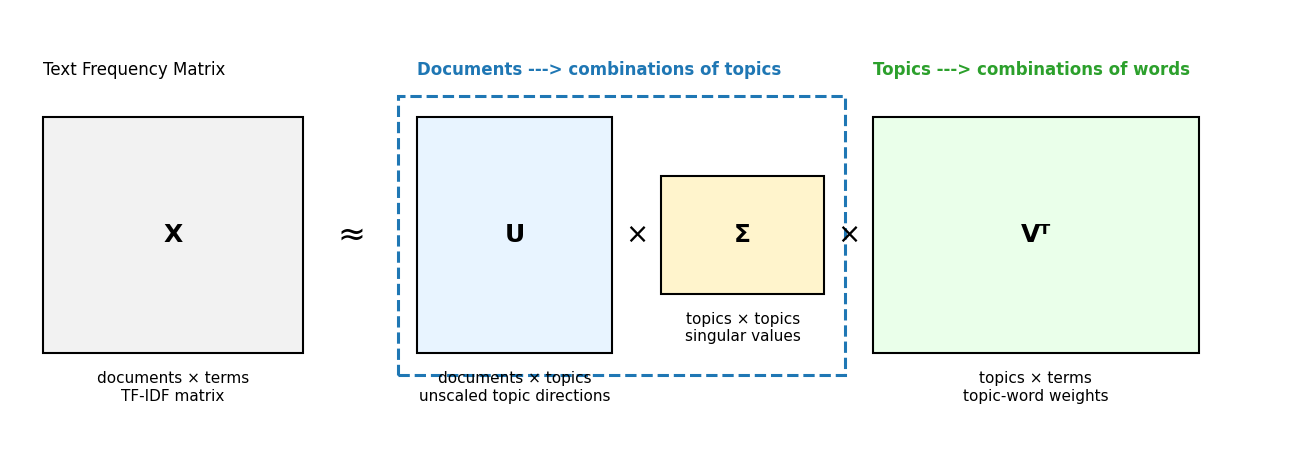

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.axis("off")

def draw_matrix(ax, x, y, w, h, label, shape, color="white"):
    rect = plt.Rectangle(
        (x, y),
        w,
        h,
        facecolor=color,
        edgecolor="black",
        linewidth=1.5
    )
    ax.add_patch(rect)

    ax.text(
        x + w/2,
        y + h/2,
        label,
        ha="center",
        va="center",
        fontsize=18,
        weight="bold"
    )

    ax.text(
        x + w/2,
        y - 0.15,
        shape,
        ha="center",
        va="top",
        fontsize=11
    )

# -----------------------------
# Draw matrices
# -----------------------------
draw_matrix(
    ax,
    x=0.2,
    y=1.0,
    w=1.6,
    h=2.0,
    label="X",
    shape="documents × terms\nTF-IDF matrix",
    color="#f2f2f2"
)

ax.text(2.1, 2.0, "≈", fontsize=24, ha="center", va="center")

draw_matrix(
    ax,
    x=2.5,
    y=1.0,
    w=1.2,
    h=2.0,
    label="U",
    shape="documents × topics\nunscaled topic directions",
    color="#e8f4ff"
)

draw_matrix(
    ax,
    x=4.0,
    y=1.5,
    w=1.0,
    h=1.0,
    label="Σ",
    shape="topics × topics\nsingular values",
    color="#fff4cc"
)

draw_matrix(
    ax,
    x=5.3,
    y=1.0,
    w=2.0,
    h=2.0,
    label="Vᵀ",
    shape="topics × terms\ntopic-word weights",
    color="#eaffea"
)

# multiplication symbols
ax.text(3.85, 2.0, "×", fontsize=20, ha="center", va="center")
ax.text(5.15, 2.0, "×", fontsize=20, ha="center", va="center")

# -----------------------------
# Highlight what sklearn returns
# -----------------------------
highlight = plt.Rectangle(
    (2.38, 0.82),
    2.75,
    2.35,
    facecolor="none",
    edgecolor="#1f77b4",
    linewidth=2.2,
    linestyle="--"
)
ax.add_patch(highlight)

# -----------------------------
# Annotations
# -----------------------------
ax.text(
    0.2,
    3.35,
    "Text Frequency Matrix",
    fontsize=12,
    ha="left"
)

ax.text(
    2.5,
    3.35,
    "Documents ---> combinations of topics",
    fontsize=12,
    ha="left",
    color="#1f77b4",
    weight="bold"
)

ax.text(
    5.3,
    3.35,
    "Topics ---> combinations of words",
    fontsize=12,
    ha="left",
    color="#2ca02c",
    weight="bold"
)

ax.set_xlim(0, 7.8)
ax.set_ylim(0.1, 3.9)

plt.tight_layout()
plt.show()

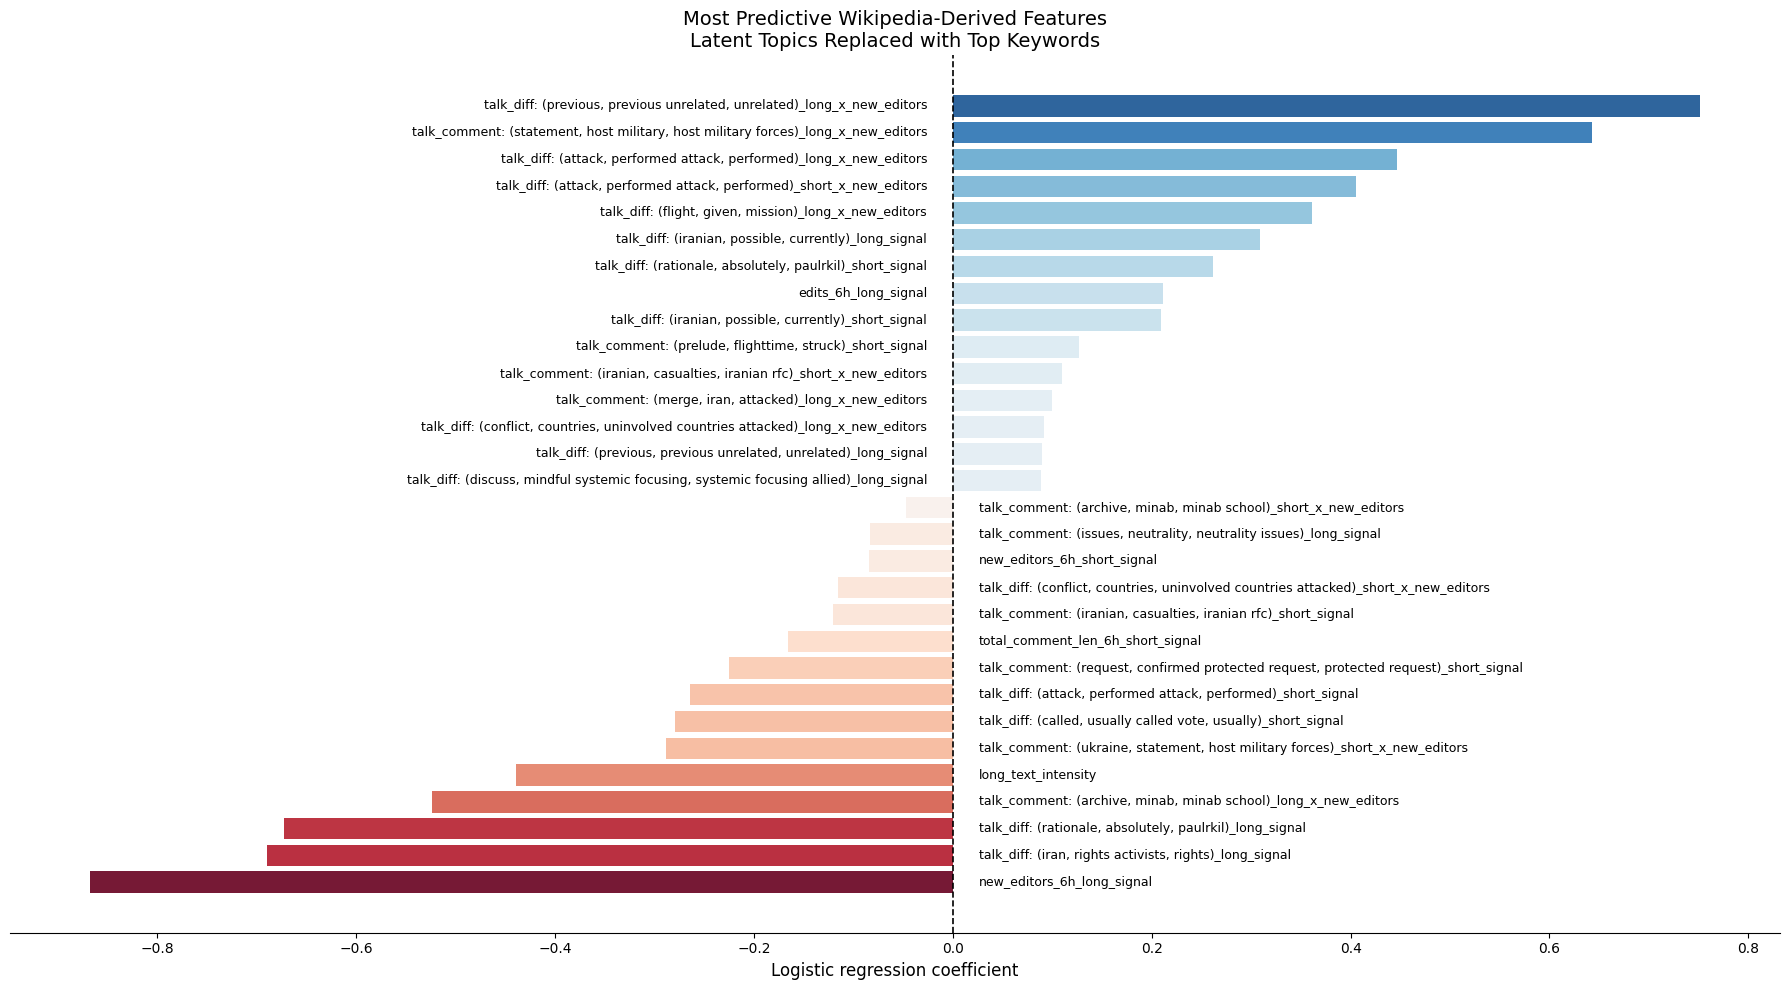

In [58]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def top_words_for_component(svd, terms, topic_idx, top_n=3):
    weights = svd.components_[topic_idx]
    top_idx = np.argsort(np.abs(weights))[::-1][:top_n]
    return ", ".join(terms[j] for j in top_idx)

def replace_svd_with_keywords(feature_name, text_models, top_n=3):
    pattern = r"(talk_diff|talk_comment)_svd_(\d+)"

    def repl(match):
        channel = match.group(1)
        topic_idx = int(match.group(2))

        if channel not in text_models:
            return match.group(0)

        model_obj = text_models[channel]

        words = top_words_for_component(
            model_obj["svd"],
            model_obj["terms"],
            topic_idx,
            top_n=top_n
        )

        return f"{channel}: ({words})"

    return re.sub(pattern, repl, feature_name)

# -------------------------------------------------
# SELECT TOP FEATURES
# -------------------------------------------------
top_n = 15

top_pos = coef_df.sort_values(
    "coef",
    ascending=False
).head(top_n)

top_neg = coef_df.sort_values(
    "coef",
    ascending=True
).head(top_n)

plot_df = pd.concat([
    top_neg,
    top_pos
]).drop_duplicates().copy()

plot_df = plot_df.sort_values("coef")

plot_df["label"] = plot_df["feature"].apply(
    lambda x: replace_svd_with_keywords(
        x,
        text_models,
        top_n=3
    )
)

# -------------------------------------------------
# COLOR MAPPING
# -------------------------------------------------
coef_max = np.max(np.abs(plot_df["coef"]))

norm = mcolors.TwoSlopeNorm(
    vmin=-coef_max,
    vcenter=0,
    vmax=coef_max
)

cmap = cm.RdBu

colors = [
    cmap(norm(v))
    for v in plot_df["coef"]
]

# -------------------------------------------------
# PLOT
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 10))

y_positions = np.arange(len(plot_df))

ax.barh(
    y=y_positions,
    width=plot_df["coef"],
    color=colors,
    alpha=0.9
)

# -------------------------------------------------
# REMOVE Y TICKS
# -------------------------------------------------
ax.set_yticks([])

# -------------------------------------------------
# CENTER LINE
# -------------------------------------------------
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2
)

# -------------------------------------------------
# LABEL ANNOTATIONS
# -------------------------------------------------
label_offset = coef_max * 0.03

for y, coef, label in zip(
    y_positions,
    plot_df["coef"],
    plot_df["label"]
):

    # positive coefficients (blue bars)
    if coef > 0:
        ax.text(
            -label_offset,
            y,
            label,
            ha="right",
            va="center",
            fontsize=9
        )

    # negative coefficients (red bars)
    else:
        ax.text(
            label_offset,
            y,
            label,
            ha="left",
            va="center",
            fontsize=9
        )

# -------------------------------------------------
# TITLES
# -------------------------------------------------
ax.set_title(
    "Most Predictive Wikipedia-Derived Features\n"
    "Latent Topics Replaced with Top Keywords",
    fontsize=14
)

ax.set_xlabel(
    "Logistic regression coefficient",
    fontsize=12
)

# -------------------------------------------------
# CLEAN LOOK
# -------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

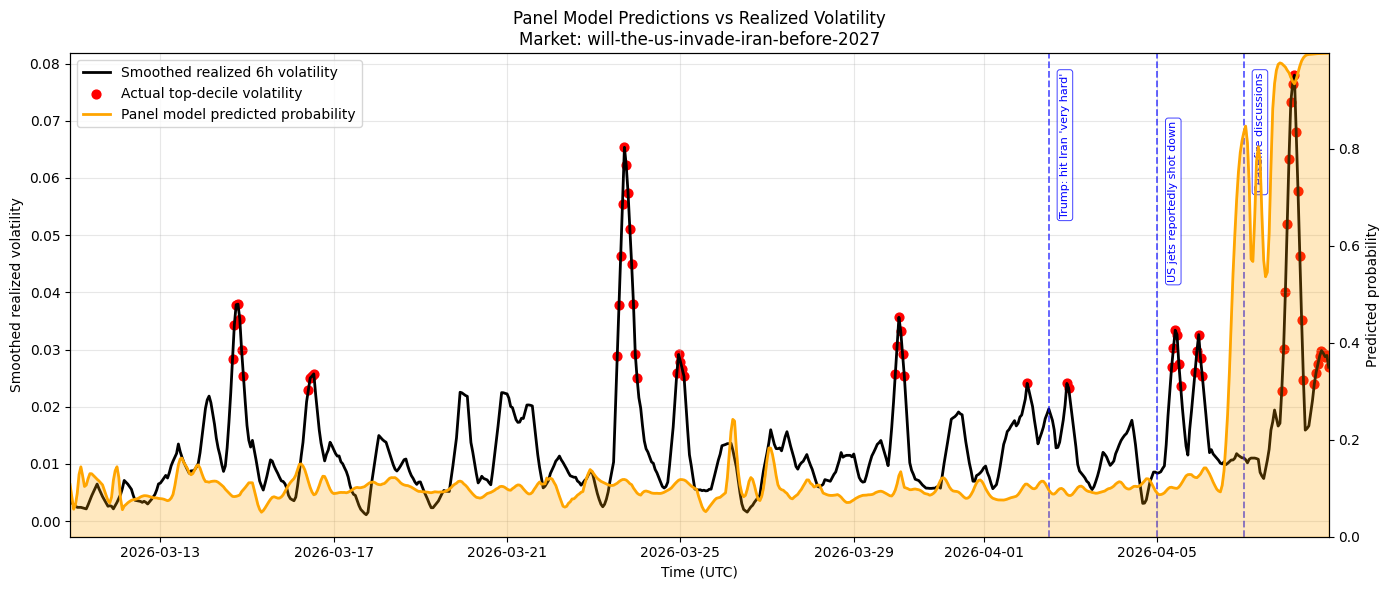

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
slug = "will-the-us-invade-iran-before-2027"
vol_col = "volatility_6h"

smooth_window = 6
vol_quantile = 0.9

# -----------------------------
# SELECT ONE MARKET
# -----------------------------
g = (
    df[df["market_slug"] == slug]
    .sort_values("timestamp")
    .copy()
)

# -----------------------------
# USE EXISTING TRAINED MODEL
# -----------------------------
plot_df = g[["timestamp", vol_col] + feature_cols].dropna().copy()

X_plot = plot_df[feature_cols]
X_plot_scaled = scaler.transform(X_plot)

plot_df["pred_prob"] = model.predict_proba(X_plot_scaled)[:, 1]
plot_df["model_score"] = model.decision_function(X_plot_scaled)

# -----------------------------
# DISPLAY VOLATILITY ONLY
# -----------------------------
plot_df["vol_smooth"] = (
    plot_df[vol_col]
    .rolling(smooth_window)
    .mean()
)

# Actual top-decile volatility for visualization only
vol_threshold = plot_df["vol_smooth"].quantile(vol_quantile)
plot_df["actual_top_decile_vol"] = plot_df["vol_smooth"] > vol_threshold

plot_df = plot_df.dropna(subset=["vol_smooth"])

# -----------------------------
# NEWS EVENTS
# -----------------------------
news_events = [
    {"time": "2026-04-02 12:00:00+00:00", "label": "Trump: hit Iran 'very hard'"},
    {"time": "2026-04-05 00:00:00+00:00", "label": "US jets reportedly shot down"},
    {"time": "2026-04-07 00:00:00+00:00", "label": "Ceasefire discussions"},
]

# -----------------------------
# PLOT
# -----------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    plot_df["timestamp"],
    plot_df["vol_smooth"],
    color="black",
    linewidth=2,
    label="Smoothed realized 6h volatility"
)

actual_spikes = plot_df["actual_top_decile_vol"]

ax1.scatter(
    plot_df.loc[actual_spikes, "timestamp"],
    plot_df.loc[actual_spikes, "vol_smooth"],
    color="red",
    s=40,
    label="Actual top-decile volatility"
)

ax1.set_ylabel("Smoothed realized volatility")
ax1.set_xlabel("Time (UTC)")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    plot_df["timestamp"],
    plot_df["pred_prob"],
    color="orange",
    linewidth=2,
    label="Panel model predicted probability"
)

ax2.fill_between(
    plot_df["timestamp"],
    0,
    plot_df["pred_prob"],
    color="orange",
    alpha=0.25
)

# dynamic probability scale
pmax = plot_df["pred_prob"].max()
ax2.set_ylim(0, max(0.05, pmax * 1.0))
ax2.set_ylabel("Predicted probability")

# News event markers
for i, event in enumerate(news_events):
    t = pd.to_datetime(event["time"], utc=True)

    ax1.axvline(
        x=t,
        color="blue",
        linestyle="--",
        linewidth=1.3,
        alpha=0.65
    )

    y_frac = 0.96 if i % 2 == 0 else 0.86

    ax1.annotate(
        event["label"],
        xy=(t, y_frac),
        xycoords=("data", "axes fraction"),
        xytext=(8, 0),
        textcoords="offset points",
        rotation=90,
        va="top",
        ha="left",
        fontsize=8,
        color="blue",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="blue",
            alpha=0.75,
            linewidth=0.7
        ),
        clip_on=True,
        zorder=10
    )

plt.title(
    f"Panel Model Predictions vs Realized Volatility\n"
    f"Market: {slug}"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.xlim(plot_df["timestamp"].min(), plot_df["timestamp"].max())
plt.tight_layout()
plt.show()

### Hawkes Process

In [ ]:
import numpy as np

# -----------------------------
# 1. Select market + clean
# -----------------------------
slug = "will-the-us-invade-iran-before-2027"

g = (
    df[df["market_slug"] == slug]
    .sort_values("timestamp")
    .copy()
)

t0 = g["timestamp"].min()
t_max = g["timestamp"].max()

# -----------------------------
# 2. Define volatility spikes
# -----------------------------
threshold = g["volatility_6h"].quantile(0.9)
g["vol_spike"] = (g["volatility_6h"] > threshold).astype(int)
g["edit_burst"] = (
    g["edits"] > g["edits"].quantile(0.9)
).astype(int)

# -----------------------------
# 3. Market event times (spikes)
# -----------------------------
market_event_times = (
    (g.loc[g["vol_spike"] == 1, "timestamp"] - t0)
    .dt.total_seconds()
    / 3600
).to_numpy()

# -----------------------------
# 4. Wiki event times (raw revisions)
# -----------------------------
# wiki_event_times = (
#     (all_revisions["timestamp"] - t0)
#     .dt.total_seconds()
#     / 3600
# )

burst_times = (
    (g.loc[g["edit_burst"] == 1, "timestamp"] - t0)
    .dt.total_seconds() / 3600
)

# restrict to same time window as market
T = (t_max - t0).total_seconds() / 3600

wiki_event_times = burst_times[
    (burst_times >= 0) &
    (burst_times <= T)
].to_numpy()

# -----------------------------
# 5. Event-study function
# -----------------------------
def count_future_spikes(source_times, target_times, horizon):
    counts = []
    for t in source_times:
        n = ((target_times > t) & (target_times <= t + horizon)).sum()
        counts.append(n)
    return np.array(counts)

# -----------------------------
# 6. Run experiment
# -----------------------------
print("Avg # of volatility spikes after a wiki edit:")

for h in [1, 3, 6, 12, 24]:
    counts = count_future_spikes(wiki_event_times, market_event_times, h)
    print(f"{h}h: {counts.mean():.4f}")

Avg # of volatility spikes after a wiki edit:
1h: 0.0732
3h: 0.2927
6h: 0.6098
12h: 0.9756
24h: 2.6341


In [26]:
# -----------------------------
# 7. Compare to random baseline
# -----------------------------
rng = np.random.default_rng(42)

random_times = rng.uniform(0, T, size=len(wiki_event_times))

print("\nComparison vs random:")

for h in [1, 3, 6, 12, 24]:
    real = count_future_spikes(wiki_event_times, market_event_times, h).mean()
    rand = count_future_spikes(random_times, market_event_times, h).mean()
    
    print(f"{h}h | real: {real:.4f} | random: {rand:.4f}")

print("-------Opposite Direction-------")
for h in [1,3,6,12,24]:
    real = count_future_spikes(market_event_times, wiki_event_times, h).mean()
    rand = count_future_spikes(random_times, wiki_event_times, h).mean()
    print(f"{h}h | real: {real:.4f} | random: {rand:.4f}")


Comparison vs random:
1h | real: 0.0732 | random: 0.2927
3h | real: 0.2927 | random: 0.7561
6h | real: 0.6098 | random: 1.5854
12h | real: 0.9756 | random: 3.4634
24h | real: 2.6341 | random: 7.4878
-------Opposite Direction-------
1h | real: 0.0139 | random: 0.0244
3h | real: 0.0625 | random: 0.2195
6h | real: 0.1806 | random: 0.3659
12h | real: 0.5000 | random: 0.5854
24h | real: 0.9444 | random: 1.0488


In [27]:
diffs = count_future_spikes(wiki_event_times, market_event_times, 6) - \
        count_future_spikes(random_times, market_event_times, 6)

print("Mean diff:", diffs.mean())
print("Std diff:", diffs.std())

boot = []
rng = np.random.default_rng(0)

for _ in range(1000):
    sample = rng.choice(diffs, size=len(diffs), replace=True)
    boot.append(sample.mean())

print("95% CI:", np.percentile(boot, [2.5, 97.5]))

Mean diff: -0.975609756097561
Std diff: 2.3215617627884475
95% CI: [-1.70731707 -0.29268293]
